In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
import numpy as np
import os
import glob
import random
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2
from matplotlib import pyplot as plt

# use dataclass
from dataclasses import dataclass, asdict
from typing import Any, Dict, List, Optional, Tuple

import albumentations as A
from albumentations.pytorch.transforms import ToTensorV2
import cv2

In [2]:
# jupyter nbconvert --to notebook --execute test.ipynb --output new_unet_baseline_v4.ipynb

In [ ]:
@dataclass
class Config:
    batch_size: int = 32
    num_epochs: int = 20
    learning_rate: float = 1e-4
    warmup_epochs: int = num_epochs * 0.1
    weight_decay: float = 1e-5
    device: str = 'cuda:1' if torch.cuda.is_available() else 'cpu'
    run_name: str = 'new_unet_baseline_v8'
    resize_size: Tuple[int, int] = (572, 572)
    base_size: Tuple[int, int] = (512, 512)
    trimap_resize_size: Tuple[int, int] = (388, 388)
    gradient_accumulation_steps: int = 2
    mini_batch_size: int = batch_size // gradient_accumulation_steps
    gradient_clip: float = 1.0
    loss_type: str = 'focal_dice'
    augmentation_type: str = 'v1'

config = Config()
config

Config(batch_size=32, num_epochs=20, learning_rate=0.0001, warmup_epochs=4.0, weight_decay=1e-05, device='cuda:1', run_name='new_unet_baseline_v8', resize_size=(572, 572), base_size=(512, 512), trimap_resize_size=(388, 388), gradient_accumulation_steps=2, mini_batch_size=16, gradient_clip=1.0, loss_type='focal_dice', augmentation_type='v1')

In [4]:
class AugmentationFactory:
    @staticmethod
    def get_augmentation(aug_type="basic", **kwargs):
        aug_type = aug_type.lower()
        if aug_type == "basic":
            return BasicAugmentation(**kwargs)
        if aug_type == "val":
            return ValAugmentation(**kwargs)
        if aug_type == "v1":
            return V1Augmentation(**kwargs)
        if aug_type == "pad_last":
            return PadLastAugmentation(**kwargs)
        else:
            raise ValueError(f"Unsupported augmentation type: {aug_type}")

class BasicAugmentation:
    def __init__(self, resize_size=(572, 572), trimap_resize_size=(388, 388), base_size=(512, 512)):
        self.resize_size = resize_size
        self.trimap_resize_size = trimap_resize_size
        self.base_size = base_size
        
        self.transform = A.Compose([
            A.RandomResizedCrop(size=self.base_size, scale=(0.6, 1.0), p=1.0),
            A.PadIfNeeded(min_height=self.resize_size[0],
                min_width=self.resize_size[1],
                border_mode=cv2.BORDER_REFLECT,
                p=1.0),

            A.HorizontalFlip(p=0.5),
            # A.Rotate(limit=10, p=0.3),
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
            A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
        ], additional_targets={'trimap': 'mask'})
        
        self.trimap_transform = A.CenterCrop(height=self.trimap_resize_size[0],
                                             width=self.trimap_resize_size[1])
        
        self.to_tensor = ToTensorV2(transpose_mask=True)
    
    def __call__(self, image, trimap):
        augmented = self.transform(image=image, trimap=trimap)
        augmented['trimap'] = self.trimap_transform(mask=augmented['trimap'])['mask']
        final = self.to_tensor(image=augmented['image'], mask=augmented['trimap'])
        return final['image'], final['mask'].unsqueeze(0)

class V1Augmentation:
    def __init__(self, resize_size=(572, 572), trimap_resize_size=(388, 388), base_size=(512, 512)):
        self.resize_size = resize_size
        self.trimap_resize_size = trimap_resize_size
        self.base_size = base_size
        
        self.transform = A.Compose([
            A.RandomResizedCrop(size=self.base_size, scale=(0.6, 1.0), p=1.0),
            A.PadIfNeeded(min_height=self.resize_size[0],
                            min_width=self.resize_size[1],
                            border_mode=cv2.BORDER_REFLECT,
                            p=1.0),
            
            A.SquareSymmetry(p=0.7),
            A.OneOf([
                A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
                A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.4),
                A.ToGray(p=0.2),
            ]),
            # A.GaussianBlur(blur_limit=(3, 7), p=0.3),
            # A.Rotate(limit=10, p=0.3),
            A.CoarseDropout(num_holes_range=(1, 8),
                            hole_height_range=(0.05, 0.15),
                            hole_width_range=(0.05, 0.15), p=0.5, fill_mask=0),
            A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
        ], additional_targets={'trimap': 'mask'})
        
        self.trimap_transform = A.CenterCrop(height=self.trimap_resize_size[0],
                                        width=self.trimap_resize_size[1])
        
        self.to_tensor = ToTensorV2(transpose_mask=True)
    
    def __call__(self, image, trimap):
        augmented = self.transform(image=image, trimap=trimap)
        augmented['trimap'] = self.trimap_transform(mask=augmented['trimap'])['mask']
        final = self.to_tensor(image=augmented['image'], mask=augmented['trimap'])
        return final['image'], final['mask'].unsqueeze(0)

class PadLastAugmentation:
    def __init__(self, resize_size=(572, 572), trimap_resize_size=(388, 388), base_size=(512, 512)):
        self.resize_size = resize_size
        self.trimap_resize_size = trimap_resize_size
        self.base_size = base_size
        
        self.transform = A.Compose([
            A.RandomResizedCrop(size=self.base_size, scale=(0.6, 1.0), p=1.0),
            A.SquareSymmetry(p=0.7),
            A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
            # A.GaussianBlur(blur_limit=(3, 7), p=0.3),
            # A.Rotate(limit=10, p=0.3),
            A.CoarseDropout(num_holes_range=(1, 8),
                            hole_height_range=(0.05, 0.15),
                            hole_width_range=(0.05, 0.15), p=0.5, fill_mask=0),
            A.PadIfNeeded(min_height=self.resize_size[0],
                min_width=self.resize_size[1],
                border_mode=cv2.BORDER_REFLECT,
                p=1.0),
            A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
        ], additional_targets={'trimap': 'mask'})
        
        self.trimap_transform = A.CenterCrop(height=self.trimap_resize_size[0],
                                        width=self.trimap_resize_size[1])
        
        self.to_tensor = ToTensorV2(transpose_mask=True)
    
    def __call__(self, image, trimap):
        augmented = self.transform(image=image, trimap=trimap)
        augmented['trimap'] = self.trimap_transform(mask=augmented['trimap'])['mask']
        final = self.to_tensor(image=augmented['image'], mask=augmented['trimap'])
        return final['image'], final['mask'].unsqueeze(0)


class ValAugmentation:
    def __init__(self, resize_size=(572, 572), trimap_resize_size=(388, 388), base_size=(512, 512)):
        self.resize_size = resize_size
        self.trimap_resize_size = trimap_resize_size
        self.base_size = base_size
        
        self.transform = A.Compose([
            A.Resize(height=self.base_size[0], width=self.base_size[1]),
            A.PadIfNeeded(min_height=self.resize_size[0],
                            min_width=self.resize_size[1],
                            border_mode=cv2.BORDER_REFLECT,
                            p=1.0),
            A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
        ], additional_targets={'trimap': 'mask'})
        
        self.trimap_transform = A.CenterCrop(height=self.trimap_resize_size[0],
                                        width=self.trimap_resize_size[1])

        self.to_tensor = ToTensorV2(transpose_mask=True)
    
    def __call__(self, image, trimap):
        augmented = self.transform(image=image, trimap=trimap)
        augmented['trimap'] = self.trimap_transform(mask=augmented['trimap'])['mask']
        final = self.to_tensor(image=augmented['image'], mask=augmented['trimap'])
        return final['image'], final['mask'].unsqueeze(0)

In [5]:
DATASET_DIR = 'dataset'

class OxfordPetsDataset(Dataset):
    def __init__(self, transform=None, split='train'):
        if split == 'train':
            self.datalist_path = os.path.join(DATASET_DIR, 'annotations', 'train.txt')
        elif split == 'val':
            self.datalist_path = os.path.join(DATASET_DIR, 'annotations', 'val.txt')
        else:
            raise ValueError(f"Unsupported split: {split}")
        
        self.split = split    
        self.datalist = open(self.datalist_path, 'r').read().splitlines()
        self.image_path = os.path.join(DATASET_DIR, 'images')
        self.trimap_path = os.path.join(DATASET_DIR, 'annotations', 'trimaps')
        self.transform = transform
        
        # self.images = [datalist.split()[0] for datalist in self.datalist]
        # self.images_class = [int(datalist.split()[1]) for datalist in self.datalist]
        self.images = self.datalist
        
    def load_image_and_mask(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.image_path, img_name + '.jpg')
        trimap_path = os.path.join(self.trimap_path, img_name + '.png')
        
        image = np.array(Image.open(img_path).convert('RGB'))
        trimap = np.array(Image.open(trimap_path))
        # map trimap to binary mask: foreground=1, background/border=0
        trimap = (trimap == 1).astype(np.uint8)
        return image, trimap
    
    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image, trimap = self.load_image_and_mask(idx)
                
        if self.transform:
            image, trimap = self.transform(image=image, trimap=trimap)
                
        return image, trimap

In [6]:
train_transform = AugmentationFactory.get_augmentation(aug_type=config.augmentation_type, resize_size=config.resize_size, trimap_resize_size=config.trimap_resize_size)
val_transform = AugmentationFactory.get_augmentation(aug_type='val', resize_size=config.resize_size, trimap_resize_size=config.trimap_resize_size)

train_dataset = OxfordPetsDataset(transform=train_transform, split='train')
val_dataset = OxfordPetsDataset(transform=val_transform, split='val')

trainloader = DataLoader(train_dataset, batch_size=config.mini_batch_size, shuffle=True, pin_memory=True, num_workers=4)
valloader = DataLoader(val_dataset, batch_size=config.mini_batch_size, shuffle=False, pin_memory=True, num_workers=4)
vis_valloader = DataLoader(val_dataset, batch_size=8, shuffle=False, pin_memory=True, num_workers=1)

images, trimaps = next(iter(trainloader))
print(images.shape, trimaps.shape)
print(images.dtype, trimaps.dtype)

torch.Size([16, 3, 572, 572]) torch.Size([16, 1, 388, 388])
torch.float32 torch.uint8


torch.Size([3, 572, 572]) torch.Size([1, 388, 388])


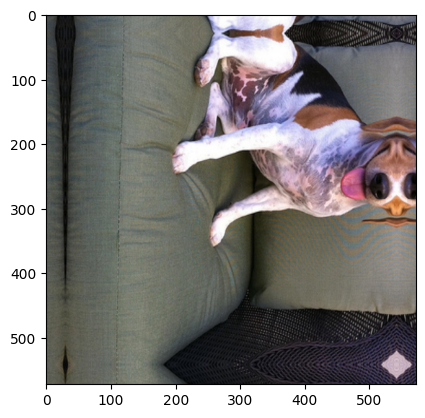

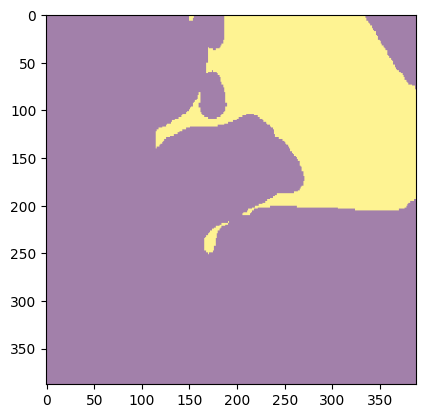

In [7]:
# idx = 4
idx = 6
images, trimaps = train_dataset[idx]
print(images.shape, trimaps.shape)

# un normalize for visualization
images = images * 0.5 + 0.5  # unnormalize
plt.imshow(images.permute(1, 2, 0))
plt.show()
plt.imshow(trimaps.permute(1, 2, 0), alpha=0.5)
plt.show()

In [8]:
class LossFactory:
    @staticmethod
    def get_loss(loss_type="bce", **kwargs):
        loss_type = loss_type.lower()
        if loss_type == "bce":
            return BCELossWrapper(**kwargs)
        elif loss_type == "focal":
            return FocalLoss(**kwargs)
        elif loss_type == "bce_focal":
            return BCEFocalLoss(**kwargs)
        elif loss_type == "focal_dice":
            return FocalDiceLoss(**kwargs)
        elif loss_type == "mixed":
            return MixedLoss(**kwargs)
        else:
            raise ValueError(f"Unsupported loss type: {loss_type}")

class BCELossWrapper(nn.Module):
    def __init__(self):
        super(BCELossWrapper, self).__init__()

    def forward(self, logits, targets):
        return F.binary_cross_entropy_with_logits(logits, targets.float())

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        targets = targets.float()
        bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        probs = torch.sigmoid(logits)
        p_t = probs * targets + (1 - probs) * (1 - targets)
        loss = self.alpha * (1 - p_t) ** self.gamma * bce_loss

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss
        
class DiceLoss(nn.Module):
    def __init__(self):
        super(DiceLoss, self).__init__()

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        targets = targets.float()
        intersection = (probs * targets).sum(dim=(1, 2, 3))
        dice_score = (2. * intersection + 1e-8) / (probs.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3)) + 1e-8)
        return 1 - dice_score.mean()

class TVLoss(nn.Module):
    def __init__(self):
        super(TVLoss, self).__init__()
    
    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        batch_size = probs.size(0)
        h_tv = torch.abs(probs[:, :, 1:, :] - probs[:, :, :-1, :]).sum()
        w_tv = torch.abs(probs[:, :, :, 1:] - probs[:, :, :, :-1]).sum()
        return (h_tv + w_tv) / batch_size

class MixedLoss(nn.Module):
    def __init__(self, alpha=0.5):
        super(MixedLoss, self).__init__()
        self.alpha = alpha
        self.bce_loss = BCELossWrapper()
        self.dice_loss = DiceLoss()
        self.tv_loss = TVLoss()

    def forward(self, logits, targets):
        bce = self.bce_loss(logits, targets)
        dice = self.dice_loss(logits, targets)
        tv = self.tv_loss(logits, targets)
        return self.alpha * (bce + dice) + (1 - self.alpha) * tv
    
class FocalDiceLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super(FocalDiceLoss, self).__init__()
        self.focal_loss = FocalLoss(alpha, gamma, reduction)
        self.dice_loss = DiceLoss()

    def forward(self, logits, targets):
        focal = self.focal_loss(logits, targets)
        dice = self.dice_loss(logits, targets)
        return focal + dice
        
class BCEFocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super(BCEFocalLoss, self).__init__()
        self.bce_loss = BCELossWrapper()
        self.focal_loss = FocalLoss(alpha, gamma, reduction)

    def forward(self, logits, targets):
        bce = self.bce_loss(logits, targets)
        focal = self.focal_loss(logits, targets)
        return bce + focal

def visualize_predictions(model, dataloader, device, vis_path, step: int):
    # predict some images on val set and visualize
    with torch.no_grad():
        for batch_idx, (images, trimaps) in enumerate(dataloader):
            images = images.to(device)
            trimaps = trimaps.to(device).float()

            outputs = model(images)
            break  # just predict one batch for visualization

    plt.figure(figsize=(12, 6))
    for i in range(min(4, images.size(0))):
        plt.subplot(2, 4, i + 1)
        img = images[i].cpu().permute(1, 2, 0) * 0.5 + 0.5  # unnormalize
        plt.imshow(img)
        plt.title("Input Image")
        plt.axis('off')

        plt.subplot(2, 4, i + 5)
        trimap = trimaps[i].cpu().squeeze(0)
        pred_mask = (torch.sigmoid(outputs[i]) > 0.5).float().cpu().squeeze(0)
        
        # Overlay trimap and prediction
        overlay = np.zeros((trimap.shape[0], trimap.shape[1], 3))
        overlay[trimap == 1] = [0, 255, 0]  # Green for foreground
        overlay[trimap == 0] = [255, 0, 0]   # Red for background
        overlay[pred_mask == 1] = [0, 0, 255] # Blue for predicted foreground
        
        plt.imshow(overlay.astype(np.uint8))
        plt.title("Trimap & Prediction")
        plt.axis('off')
    plt.tight_layout()
    save_path = os.path.join(vis_path, f"predictions_step_{step}.png")
    plt.savefig(save_path)
    

import torch
import numpy as np
import time
from collections import defaultdict

class MetricFactory:
    @staticmethod
    def get_metrics(metric_names, threshold=0.5):
        metrics = {}
        for name in metric_names:
            name = name.lower()
            if name == "iou":
                metrics["iou"] = IoUMetric(threshold)
            elif name == "dice":
                metrics["dice"] = DiceMetric(threshold)
            elif name == "accuracy":
                metrics["accuracy"] = AccuracyMetric(threshold)
        return metrics

class BaseMetric:
    def __init__(self, threshold=0.5):
        self.threshold = threshold

    def __call__(self, logits, targets):
        raise NotImplementedError

class IoUMetric(BaseMetric):
    def __call__(self, logits, targets):
        preds = (torch.sigmoid(logits) > self.threshold).float()
        intersection = (preds * targets).sum(dim=(1, 2, 3))
        union = (preds + targets).clamp(0, 1).sum(dim=(1, 2, 3))
        iou = (intersection + 1e-7) / (union + 1e-7)
        return iou.mean().item()

class DiceMetric(BaseMetric):
    def __call__(self, logits, targets):
        preds = (torch.sigmoid(logits) > self.threshold).float()
        intersection = (preds * targets).sum(dim=(1, 2, 3))
        dice = (2. * intersection + 1e-7) / (preds.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3)) + 1e-7)
        return dice.mean().item()

class AccuracyMetric(BaseMetric):
    def __call__(self, logits, targets):
        preds = (torch.sigmoid(logits) > self.threshold).float()
        correct = (preds == targets).float().mean()
        return correct.item()

class MetricManager:
    def __init__(self, loss_type="bce", metric_names=["iou", "dice"], logger=None, threshold=0.3, total_steps=None, eta_every_log=True):
        self.criterion = LossFactory.get_loss(loss_type)
        self.metrics_dict = MetricFactory.get_metrics(metric_names, threshold)
        self.logger = logger
        self.total_steps = total_steps
        self.eta_every_log = eta_every_log
        self.start_time = time.time()
        self.logged_steps = 0

        self.reset_epoch_stats()

    @staticmethod
    def _format_seconds(seconds):
        seconds = int(max(0, seconds))
        h, rem = divmod(seconds, 3600)
        m, s = divmod(rem, 60)
        return f"{h:02d}:{m:02d}:{s:02d}"

    def reset_epoch_stats(self):
        self.epoch_data = defaultdict(list)

    def _estimate_eta(self):
        self.logged_steps += 1
        elapsed = time.time() - self.start_time
        avg_step_time = elapsed / max(1, self.logged_steps)

        eta_seconds = None
        if self.total_steps is not None:
            remaining_steps = max(0, self.total_steps - self.logged_steps)
            eta_seconds = remaining_steps * avg_step_time

        return elapsed, avg_step_time, eta_seconds

    def update(self, logits, targets, step=None, prefix="train/"):
        results = {}

        loss = self.criterion(logits, targets)
        results[f"{prefix}loss"] = loss.item()

        for name, metric_fn in self.metrics_dict.items():
            val = metric_fn(logits, targets)
            results[f"{prefix}{name}"] = val

        elapsed, avg_step_time, eta_seconds = self._estimate_eta()

        if self.logger:
            if step is not None and step % 50 == 0:
                self.logger.log(results, step=step, verbose=True)
                if self.total_steps is not None:
                    print(
                        f"[ETA] {prefix.rstrip('/')} | progress: {self.logged_steps}/{self.total_steps} "
                        f"| elapsed: {self._format_seconds(elapsed)} "
                        f"| remaining: {self._format_seconds(eta_seconds)} "
                        f"| avg_step: {avg_step_time:.2f}s"
                    )

            else:
                self.logger.log(results, step=step, verbose=False)

            # if self.eta_every_log:
            #     if self.total_steps is not None:
            #         print(
            #             f"[ETA] {prefix.rstrip('/')} | progress: {self.logged_steps}/{self.total_steps} "
            #             f"| elapsed: {self._format_seconds(elapsed)} "
            #             f"| remaining: {self._format_seconds(eta_seconds)} "
            #             f"| avg_step: {avg_step_time:.2f}s"
            #         )
                # else:
                #     print(
                #         f"[ETA] {prefix.rstrip('/')} | elapsed: {self._format_seconds(elapsed)} "
                #         f"| avg_step: {avg_step_time:.2f}s"
                #     )

        for k, v in results.items():
            self.epoch_data[k].append(v)

        return loss

    def get_epoch_averages(self):
        return {k: np.mean(v) for k, v in self.epoch_data.items()}

In [9]:
from src.models import UNet
from src.utils import SimpleLogger, FocalLoss
from sklearn.metrics import roc_curve, auc
import torch.nn.functional as F
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR


device = 'cuda:1' if torch.cuda.is_available() else 'cpu'

model = UNet(in_channels=3, out_channels=1)
model = model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay)
scheduler1 = LinearLR(optimizer, start_factor=0.05, total_iters=config.warmup_epochs)
scheduler2 = CosineAnnealingLR(optimizer, T_max=config.num_epochs)
scheduler = SequentialLR(optimizer, schedulers=[scheduler1, scheduler2], milestones=[config.warmup_epochs])

logger = SimpleLogger('logs', run_name=config.run_name)
total_log_steps = config.num_epochs * (len(trainloader) + len(valloader))
metric_manager = MetricManager(
    loss_type="bce", 
    metric_names=["iou", "dice", "accuracy"],
    logger=logger,
    total_steps=total_log_steps
)
logger.save_config(asdict(config))

for epoch in range(config.num_epochs):
    print(f'Epoch {epoch+1}/{config.num_epochs}')
    metric_manager.reset_epoch_stats()
    model.train()
    
    # Training loop
    for batch_idx, (images, trimaps) in enumerate(trainloader):
        step = epoch * len(trainloader) + batch_idx
        images = images.to(device)
        trimaps = trimaps.to(device).float()
        
        outputs = model(images)
        total_loss = metric_manager.update(outputs, trimaps, step=step, prefix="train/")
        total_loss.backward()
        
        if (batch_idx + 1) % config.gradient_accumulation_steps == 0:
            if config.gradient_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), config.gradient_clip)
            optimizer.step()
            optimizer.zero_grad()
            
        # if batch_idx > 2:
        #     break # early stop for faster debugging
    
    model.eval()
    
    print(metric_manager.logger.vis_path)
    visualize_predictions(model, vis_valloader, device, metric_manager.logger.vis_path, step=epoch)
        
    with torch.no_grad():
        for batch_idx, (images, trimaps) in enumerate(valloader):
            step = epoch * len(valloader) + batch_idx
            images = images.to(device)
            trimaps = trimaps.to(device).float()

            outputs = model(images)
            
            total_loss = metric_manager.update(outputs, trimaps, step=step, prefix="val/")
            
    logger.plot()
    epoch_averages = metric_manager.get_epoch_averages()
    nice_str = f"[Epoch {epoch}] " + " | ".join([f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}" for k, v in epoch_averages.items()])
    print(nice_str)
    scheduler.step()


Epoch 1/20
[Step 0] train/loss: 0.9234 | train/iou: 0.5231 | train/dice: 0.6648 | train/accuracy: 0.5231
[ETA] train | progress: 1/7420 | elapsed: 00:00:01 | remaining: 02:47:02 | avg_step: 1.35s
[Step 50] train/loss: 0.8108 | train/iou: 0.4756 | train/dice: 0.6035 | train/accuracy: 0.4759
[ETA] train | progress: 51/7420 | elapsed: 00:01:06 | remaining: 02:41:08 | avg_step: 1.31s


KeyboardInterrupt: 

In [ ]:
torch.save(model, metric_manager.logger.saved_model_path)

In [ ]:
# sweep over different thresholds on eval set for metrics

model.eval()
thresholds = np.arange(0.1, 0.9, 0.1)
for threshold in thresholds:
    metric_manager = MetricManager(
        loss_type="bce", 
        metric_names=["iou", "dice", "accuracy"],
        logger=logger,
        threshold=threshold
    )
    
    with torch.no_grad():
        for batch_idx, (images, trimaps) in enumerate(valloader):
            images = images.to(device)
            trimaps = trimaps.to(device).float()

            outputs = model(images)
            total_loss = metric_manager.update(outputs, trimaps, step=batch_idx, prefix=f"val_thresh_{threshold:.1f}/")
    logger.plot()


In [ ]:
# # Check what the model is actually predicting
# model.eval()
# images_sample, trimaps_sample, _ = next(iter(trainloader))
# images_sample = images_sample.to(device)

# with torch.no_grad():
#     logits = model(images_sample)
#     probs = torch.sigmoid(logits)

# print("=== Model Output Analysis ===")
# print(f"Logits - Min: {logits.min():.4f}, Mean: {logits.mean():.4f}, Max: {logits.max():.4f}, Std: {logits.std():.4f}")
# print(f"Sigmoid(logits) - Min: {probs.min():.4f}, Mean: {probs.mean():.4f}, Max: {probs.max():.4f}, Std: {probs.std():.4f}")
# print(f"Percentage predicted > 0.5: {(probs > 0.5).float().mean():.4f}")
# print(f"Percentage predicted > 0.3: {(probs > 0.3).float().mean():.4f}")
# print(f"Percentage predicted > 0.7: {(probs > 0.7).float().mean():.4f}")
# print(f"\nTrimaps in batch - Min: {trimaps_sample.min():.4f}, Mean: {trimaps_sample.mean():.4f}, Max: {trimaps_sample.max():.4f}")

In [ ]:
# plt.hist(heights, bins=100, alpha=0.5, label='Heights')
# plt.hist(widths, bins=100, alpha=0.5, label='Widths')
# plt.xlabel('Pixels')
# plt.ylabel('Frequency')
# plt.loglog()  # Use log-log scale for better visibility of distribution
# plt.title('Distribution of Image Heights and Widths')
# plt.legend()
# plt.show()